In [1]:
# ==========================================================
# Imports
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print("Imports Loaded ✓")

Imports Loaded ✓


In [2]:
from pathlib import Path

for p in Path("/kaggle/input/notebooks").rglob("*"):
    print(p)

/kaggle/input/notebooks/shri7ul
/kaggle/input/notebooks/shri7ul/02-eda-ipynb
/kaggle/input/notebooks/shri7ul/master-dataset-creation
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb
/kaggle/input/notebooks/shri7ul/02-eda-ipynb/__results__.html
/kaggle/input/notebooks/shri7ul/02-eda-ipynb/__notebook__.ipynb
/kaggle/input/notebooks/shri7ul/02-eda-ipynb/__results___files
/kaggle/input/notebooks/shri7ul/02-eda-ipynb/__output__.json
/kaggle/input/notebooks/shri7ul/02-eda-ipynb/custom.css
/kaggle/input/notebooks/shri7ul/master-dataset-creation/master
/kaggle/input/notebooks/shri7ul/master-dataset-creation/__results__.html
/kaggle/input/notebooks/shri7ul/master-dataset-creation/__notebook__.ipynb
/kaggle/input/notebooks/shri7ul/master-dataset-creation/__output__.json
/kaggle/input/notebooks/shri7ul/master-dataset-creation/custom.css
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/__results__.html
/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feat

In [3]:
# ==========================================================
# Load Feature Engineered Dataset
# ==========================================================

FEATURE_PATH = Path(
    "/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet"
)

master = pd.read_parquet(FEATURE_PATH)

print(master.shape)

master.head()

(35072, 122)


,response_id,session_id,learning_objective_id,learning_objective,transcript,student_text,tutor_text,background_text,is_correct,objective_frequency,...,log_unclear_count,log_digit_count,log_math_symbol_count,log_encouragement_score,log_instruction_score,log_student_uncertainty_score,background_heavy,many_questions,many_unclear,long_session
0,aaaavsh,bcaufvc,dqibnvd,Knowing the value of each digit in numbers wit...,"[BACKGROUND] [unclear]\n[TUTOR] Miss, I can't ...","Can you hear me? Hello? Yeah, I hear you. Can ...","Miss, I can't hear. Can you hear me? [unclear]...","[unclear] Good, very good. [unclear] And we wi...",1.0,1267,...,4.595120,5.926926,2.564949,3.433987,4.007333,0.693147,0,0,1,0
1,aaabhzi,eyutanf,eukmzxl,Adding and subtracting tens to a 2-digit number.,[TUTOR] Yay! Hello!\n[STUDENT] Hello.\n[TUTOR]...,Hello. Hello. I was one minute early. I'm one ...,Yay! Hello! Hello. Hello. [Speaker:Background]...,20. What 2-digit number can you make using the...,1.0,44,...,4.382027,6.198479,3.828641,3.891820,4.624973,2.484907,0,0,0,1
2,aaahpnz,juptkxd,fjbqcsv,Comparing and ordering fractions by finding a ...,[BACKGROUND] [unclear]\n[TUTOR] Is it me you a...,Hello. Hello. Yes. Good. How are you? Normal. ...,"Is it me you are looking for? Okay, so did you...","[unclear] Hello. Hello, Callum. Can you hear m...",0.0,211,...,4.532599,6.658011,4.406719,4.248495,4.158883,1.609438,0,0,1,1
3,aaajpom,ntwkcfj,acvbcev,Comparing fractions using reasoning.,[BACKGROUND] [unclear]\n[TUTOR] Hello?\n[STUDE...,"Hello, Tobias. Can you hear me? Okay, that's n...","Hello? Yes, I can hear you. Good. Why are you ...","[unclear] 1.45 meters. Excellent. Yes, good. G...",0.0,510,...,4.394449,6.603944,3.332205,4.672829,4.543295,2.564949,0,1,0,1
4,aaamwux,jqriibm,krfuudx,Counting in multiples.,[BACKGROUND] [unclear]\n[TUTOR] Hello.\n[STUDE...,"Hello. Good. Okay, how was this week for you? ...",Hello. Hello. Are you feeling tired today? Is ...,"[unclear] Hello. Hi, Caelum. How are you doing...",0.0,525,...,4.510860,6.066108,0.693147,3.737670,3.663562,1.609438,0,1,1,0


In [4]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*60)

print("Rows :", len(master))

print("Columns :", len(master.columns))

print("Target Distribution")

display(
    master["is_correct"]
    .value_counts(normalize=True)
    .rename("Percentage")
)

print("="*60)

Rows : 35072
Columns : 122
Target Distribution


is_correct
1.0    0.702469
0.0    0.297531
Name: Percentage, dtype: float64

In [5]:
# ==========================================================
# Prepare Features
# ==========================================================

TARGET = "is_correct"

DROP_COLUMNS = [

    # IDs
    "response_id",
    "session_id",

    # Raw text
    "learning_objective",
    "learning_objective_id",
    "transcript",
    "student_text",
    "tutor_text",
    "background_text",

    # Target
    TARGET,
]

X = master.drop(columns=DROP_COLUMNS)

y = master[TARGET].astype(int)

print(X.shape)

print(y.shape)

(35072, 113)
(35072,)


In [6]:
# ==========================================================
# Encode Categoricals
# ==========================================================

categorical_cols = X.select_dtypes(include="object").columns.tolist()

print(categorical_cols)

for col in categorical_cols:
    X[col] = X[col].astype("category").cat.codes

print("Categorical Encoding Complete ✓")

['objective_family']
Categorical Encoding Complete ✓


In [7]:
# ==========================================================
# Final Feature Matrix
# ==========================================================

display(X.head())

print()

print("Features :", X.shape[1])

print()

print(X.dtypes.value_counts())

,objective_frequency,log_objective_frequency,is_rare_objective,objective_frequency_percentile,objective_char_count,objective_word_count,objective_avg_word_length,obj_has_fraction,obj_has_decimal,obj_has_money,...,log_unclear_count,log_digit_count,log_math_symbol_count,log_encouragement_score,log_instruction_score,log_student_uncertainty_score,background_heavy,many_questions,many_unclear,long_session
0,1267,7.145196,0,0.942803,71,14,5.071429,0,1,0,...,4.595120,5.926926,2.564949,3.433987,4.007333,0.693147,0,0,1,0
1,44,3.806662,0,0.061089,49,8,6.125000,0,0,0,...,4.382027,6.198479,3.828641,3.891820,4.624973,2.484907,0,0,0,1
2,211,5.356586,0,0.259466,65,9,7.222222,1,0,0,...,4.532599,6.658011,4.406719,4.248495,4.158883,1.609438,0,0,1,1
3,510,6.236370,0,0.699803,36,4,9.000000,1,0,0,...,4.394449,6.603944,3.332205,4.672829,4.543295,2.564949,0,1,0,1
4,525,6.265301,0,0.714559,22,3,7.333333,0,0,0,...,4.510860,6.066108,0.693147,3.737670,3.663562,1.609438,0,1,1,0



Features : 113

int64      50
float64    37
int8       26
Name: count, dtype: int64


In [8]:
from catboost import CatBoostClassifier

print("CatBoost Ready ✓")

CatBoost Ready ✓


In [9]:
# ==========================================================
# CatBoost Baseline (5 Fold CV)
# ==========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof_pred = np.zeros(len(X))
scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):

    print("="*60)
    print(f"Fold {fold}")
    print("="*60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(

        iterations=1000,
        learning_rate=0.03,
        depth=6,

        loss_function="Logloss",
        eval_metric="AUC",

        random_seed=42,

        verbose=False,
    )

    model.fit(

        X_train,
        y_train,

        eval_set=(X_valid, y_valid),

        use_best_model=True,

        verbose=False,
    )

    pred = model.predict_proba(X_valid)[:,1]

    oof_pred[valid_idx] = pred

    auc = roc_auc_score(y_valid, pred)

    scores.append(auc)

    print(f"AUC : {auc:.6f}")

print()

print("="*60)

print("Fold Scores")

print(scores)

print()

print("Mean AUC :", np.mean(scores))

print("Std AUC  :", np.std(scores))

print("="*60)

Fold 1
AUC : 0.730587
Fold 2
AUC : 0.713199
Fold 3
AUC : 0.718762
Fold 4
AUC : 0.718046
Fold 5
AUC : 0.712667

Fold Scores
[np.float64(0.7305873480855511), np.float64(0.7131990553768225), np.float64(0.7187622566908586), np.float64(0.7180462933238312), np.float64(0.712667231955501)]

Mean AUC : 0.7186524370865129
Std AUC  : 0.00645575129157526


In [10]:
# ==========================================================
# Overall OOF Score
# ==========================================================

overall_auc = roc_auc_score(y, oof_pred)

print("="*60)

print(f"Overall OOF AUC : {overall_auc:.6f}")

print("="*60)

Overall OOF AUC : 0.718599


In [11]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.DataFrame({

    "feature": X.columns,
    "importance": model.get_feature_importance()

})

importance = (
    importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(30))

,feature,importance
0,objective_avg_word_length,8.574545
1,objective_char_count,8.473574
2,objective_frequency_percentile,3.767647
3,log_objective_frequency,3.680962
4,objective_frequency,3.653774
5,objective_word_count,2.318653
6,obj_has_decimal,2.005179
7,student_words_per_turn,2.005001
8,encouragement_per_turn,1.967211
9,student_question_count,1.942856


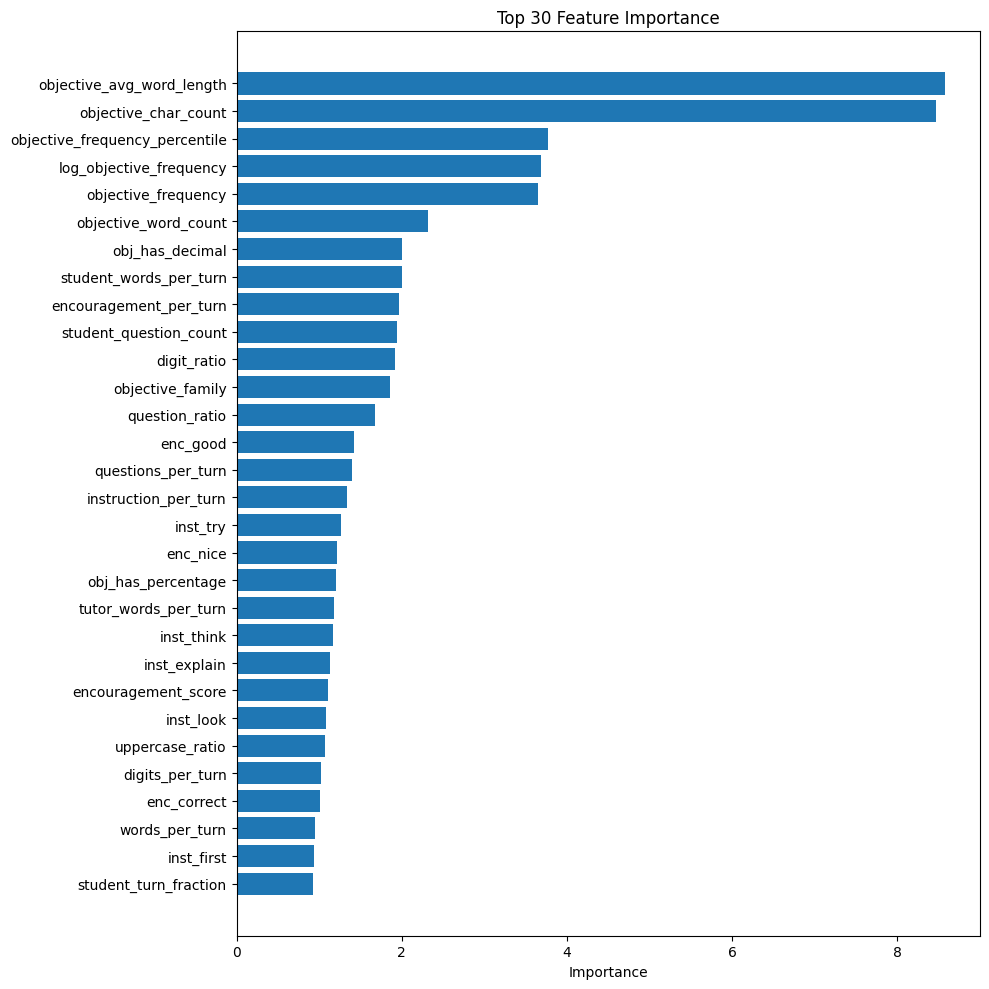

In [12]:
import matplotlib.pyplot as plt

top = importance.head(30).iloc[::-1]

plt.figure(figsize=(10,10))

plt.barh(
    top["feature"],
    top["importance"]
)

plt.title("Top 30 Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [13]:
model = CatBoostClassifier(

    iterations=3000,
    learning_rate=0.02,
    depth=6,

    loss_function="Logloss",
    eval_metric="Logloss",

    random_seed=42,

    od_type="Iter",
    od_wait=200,

    verbose=200
)

In [14]:
# ==========================================================
# CatBoost Baseline (5 Fold CV - LogLoss)
# ==========================================================

import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof_pred = np.zeros(len(X))
scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), start=1):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(

        iterations=5000,
        learning_rate=0.02,
        depth=6,

        loss_function="Logloss",
        eval_metric="Logloss",

        od_type="Iter",
        od_wait=300,

        random_seed=42,

        use_best_model=True,

        verbose=200,
    )

    model.fit(

        X_train,
        y_train,

        eval_set=(X_valid, y_valid),

        verbose=200,
    )

    pred = model.predict_proba(X_valid)[:, 1]

    oof_pred[valid_idx] = pred

    loss = log_loss(y_valid, pred)

    scores.append(loss)

    print(f"\nFold {fold} LogLoss : {loss:.6f}")
    print()

print("=" * 60)
print("Fold LogLoss")
print(scores)
print()

print(f"Mean LogLoss : {np.mean(scores):.6f}")
print(f"Std LogLoss  : {np.std(scores):.6f}")
print("=" * 60)

overall_loss = log_loss(y, oof_pred)

print()
print("=" * 60)
print(f"Overall OOF LogLoss : {overall_loss:.6f}")
print("=" * 60)

Fold 1
0:	learn: 0.6892966	test: 0.6892992	best: 0.6892992 (0)	total: 19ms	remaining: 1m 35s
200:	learn: 0.5564786	test: 0.5614099	best: 0.5614099 (200)	total: 3.77s	remaining: 1m 30s
400:	learn: 0.5405302	test: 0.5534272	best: 0.5534272 (400)	total: 7.51s	remaining: 1m 26s
600:	learn: 0.5264319	test: 0.5483449	best: 0.5483327 (598)	total: 11.2s	remaining: 1m 21s
800:	learn: 0.5116181	test: 0.5452601	best: 0.5452601 (800)	total: 14.8s	remaining: 1m 17s
1000:	learn: 0.4980699	test: 0.5433411	best: 0.5433250 (999)	total: 18.5s	remaining: 1m 13s
1200:	learn: 0.4860942	test: 0.5418216	best: 0.5418115 (1198)	total: 22.1s	remaining: 1m 10s
1400:	learn: 0.4744595	test: 0.5409411	best: 0.5409411 (1400)	total: 25.8s	remaining: 1m 6s
1600:	learn: 0.4639344	test: 0.5402949	best: 0.5402879 (1597)	total: 29.5s	remaining: 1m 2s
1800:	learn: 0.4538908	test: 0.5401575	best: 0.5401575 (1800)	total: 33.1s	remaining: 58.7s
2000:	learn: 0.4442078	test: 0.5400353	best: 0.5400107 (1993)	total: 36.8s	remaini